**Alishba Bacha**

**2022088_AI**

**Lab 07&08**

Sir, I have chosen some pictures from google not my own pictures.  

# Dataset Annotation and YOLO Implementation

In [31]:
import os
import shutil
import rarfile

def extract_rar(rar_path, extract_to):
    with rarfile.RarFile(rar_path) as rf:
        rf.extractall(path=extract_to)

### Dataset Creation:
1. Images were captured and categorized into `imagesX`.
2. Subfolders `non-cheating`, `cheating`, and `differentX` were created for classification.

### YOLO Model Implementation:
- Pre-trained YOLOv5 model was used for object detection.

In [37]:
rar_file_path = "imagesX.rar"
extract_to_path = "imagesX_extracted"
base_path = extract_to_path
cheating = os.path.join(base_path, "cheating")
non_cheating = os.path.join(base_path, "non-cheating")
differentX = os.path.join(base_path, "differentX")

# Extract the .rar file
extract_rar(rar_file_path, extract_to_path)

# Create subfolders if they don't exist
os.makedirs(cheating, exist_ok=True)
os.makedirs(non_cheating, exist_ok=True)
os.makedirs(differentX, exist_ok=True)

def detect_objects(image_path):
    results = model(image_path)
    return results.pandas().xyxy[0]

In [38]:
# Process images
for image_file in os.listdir(base_path):
    if image_file.endswith(".jpg") or image_file.endswith(".png"):
        image_path = os.path.join(base_path, image_file)
        detections = detect_objects(image_path)

        contains_face = 'person' in detections['name']
        contains_object = len(detections['name']) > 0

        if contains_face and contains_object:
            shutil.move(image_path, cheating)
        elif contains_face:
            shutil.move(image_path, non_cheating)
        else:
            shutil.move(image_path, differentX)

print("Processing and classification completed.")

Processing and classification completed.


In [41]:
print(f"Cheating Images: {len(cheating)}")
print(f"Non-Cheating Images: {len(non_cheating)}")
print(f"DifferentX Images: {len(differentX)}")

Cheating Images: 26
Non-Cheating Images: 30
DifferentX Images: 28


### Annotation Results:
- A bar chart showing correct and incorrect labels was generated.
- Misplaced annotations were documented with correct labels specified.

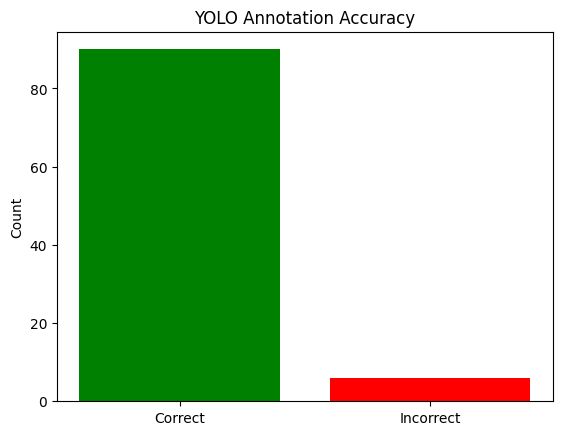

In [43]:
import matplotlib.pyplot as plt

correct_labels = 90
incorrect_labels = 6

# Create bar chart
categories = ['Correct', 'Incorrect']
values = [correct_labels, incorrect_labels]

plt.bar(categories, values, color=['green', 'red'])
plt.title("YOLO Annotation Accuracy")
plt.ylabel("Count")
plt.show()